## *Group ID : PTID-CDS-MAY-26-11227*
##
*Project ID : PRCP-1016-HeartDieseasePred*

*All the useful information is present in two dataframes with ‘patient_id’ being the common column. So as the first step, you need to merge these two data files so that you have all the useful data combined into a single master dataframe.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,recall_score, classification_report, roc_auc_score,confusion_matrix

In [2]:
Data = pd.read_csv("values.csv")
Data.head(5)

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0


In [3]:
Data1 = pd.read_csv("labels.csv")
Data1.head(5)

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0


In [4]:
Data.shape

(180, 14)

In [5]:
Data1.shape

(180, 2)

In [6]:
df = pd.merge(Data, Data1, on="patient_id", how="outer")
df.head(5)

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,02cipp,1,normal,140,1,2,0,0,239,1.8,0,69,151,0,0
1,08usun,1,reversible_defect,120,4,0,0,0,177,0.4,1,65,140,0,0
2,0g192k,2,reversible_defect,128,4,1,0,0,263,0.2,1,64,105,1,0
3,0n5fu0,1,normal,180,4,0,0,0,325,0.0,0,64,154,1,0
4,0ryxtv,2,normal,102,4,0,0,2,265,0.6,0,42,122,0,0


In [7]:
df['fasting_blood_sugar_gt_120_mg_per_dl'].value_counts()

,count
fasting_blood_sugar_gt_120_mg_per_dl,
0,151
1,29


In [8]:
df_copy = df.copy()

In [9]:
df.shape

(180, 15)

In [10]:
df.size

2700

In [11]:
df.isnull().sum()

,0
patient_id,0
slope_of_peak_exercise_st_segment,0
thal,0
resting_blood_pressure,0
chest_pain_type,0
num_major_vessels,0
fasting_blood_sugar_gt_120_mg_per_dl,0
resting_ekg_results,0
serum_cholesterol_mg_per_dl,0
oldpeak_eq_st_depression,0


In [12]:
# There is No Null Values Present in this Dataset

In [13]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [15]:
df.drop(["patient_id"],inplace=True,axis=1)
# Ptient_id column is not required

In [16]:
df.columns

Index(['slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [17]:
df.duplicated().sum()

np.int64(0)

**Uni Vaient Analysis**

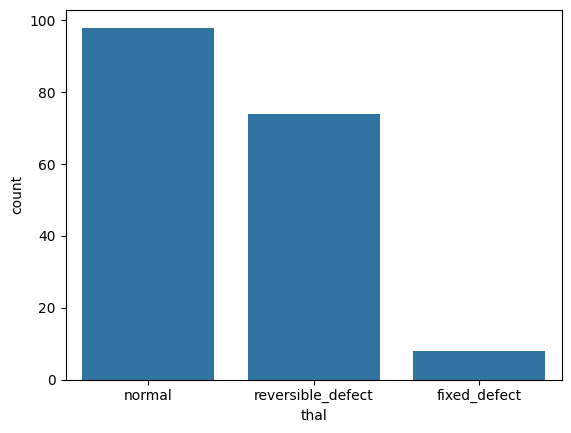

In [18]:
sns.countplot(x=df["thal"])
plt.show()

In [19]:
import plotly.express as px
fig = px.histogram(x=df["thal"])
fig.show()

Insights:
1.The majority of individuals in this sample have a "normal" result, with the count nearing 100. This indicates healthy, consistent blood flow to the heart muscle.
2.There is a substantial number of "reversible_defect" cases (approximately 75). In clinical terms, this suggests these individuals experience restricted blood flow during physical stress, which is a key indicator of heart disease.
3.The "fixed_defect" category is the least frequent, with a count of less than 10. This indicates that very few individuals in this specific cohort have permanent heart muscle scarring from previous cardiac events.

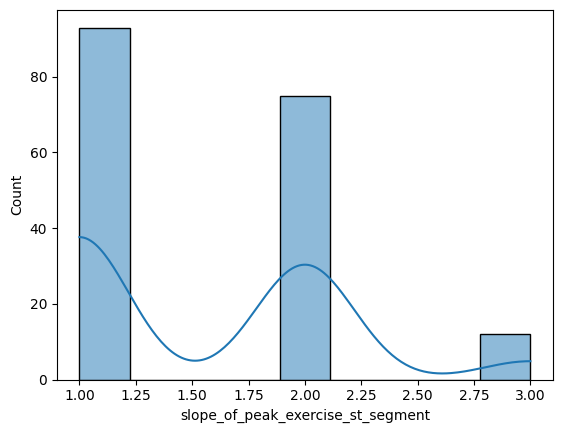

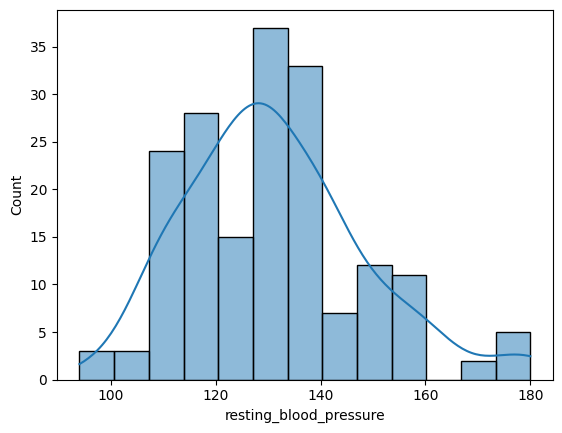

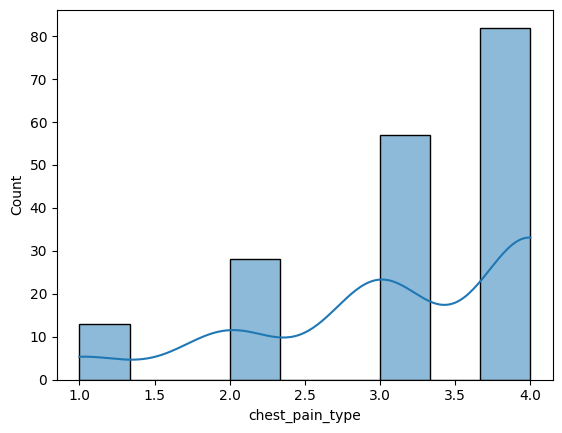

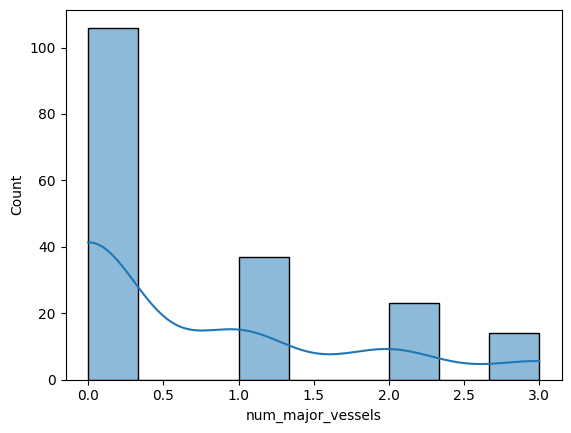

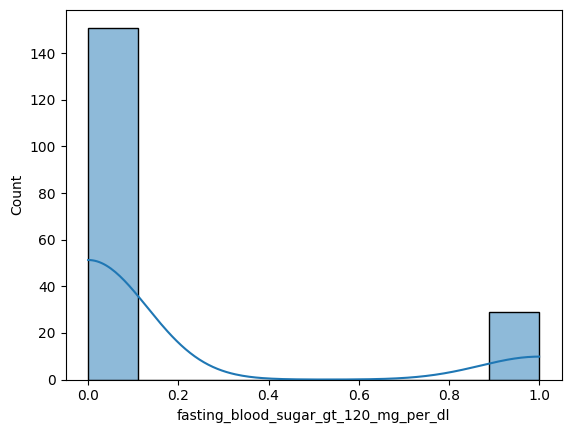

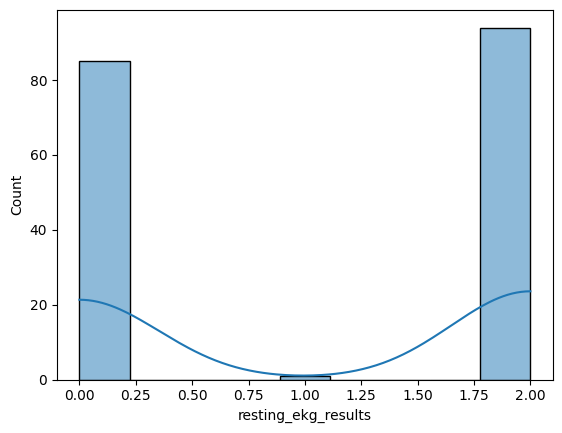

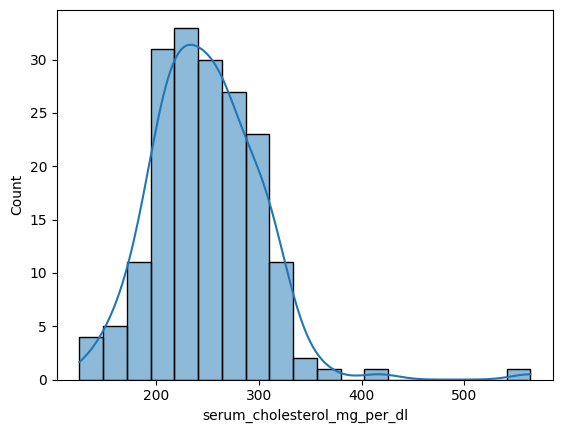

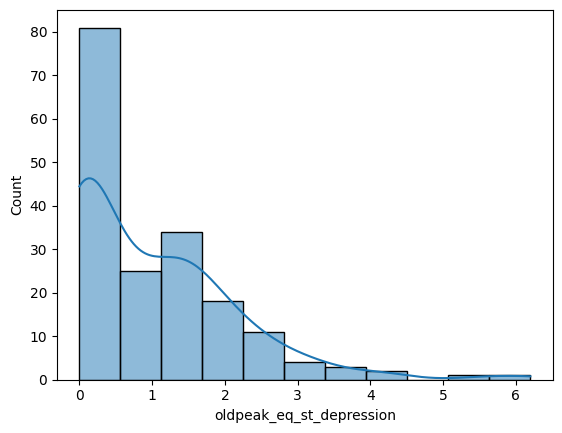

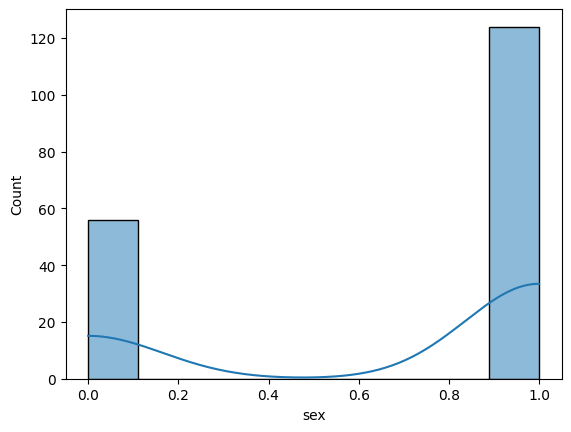

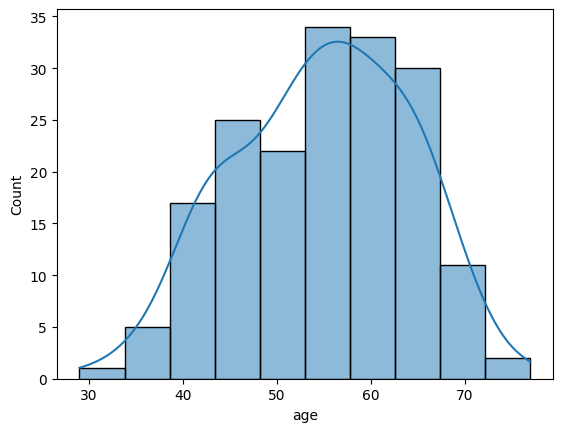

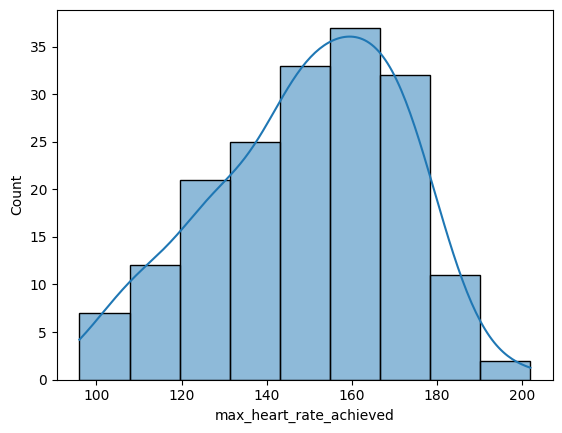

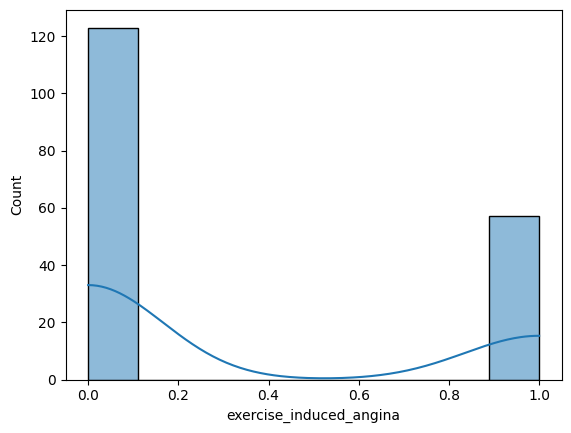

In [20]:
C = ['slope_of_peak_exercise_st_segment', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina']
for i in C:
  sns.histplot(df[i],kde=True)
  plt.show()

1.slope_of_peak_exercise_st_segment: Most individuals have a slope of 1, indicating an upsloping ST segment, which is generally considered a normal response to exercise. A smaller group has a slope of 2 (horizontal), and very few have a slope of 3 (downsloping), which can be indicative of cardiac issues.
2. The majority of individuals experience chest pain types 3 and 4
3. num_major_vessels: Most individuals have 0 major vessels
4.fasting_blood_sugar_gt_120_mg_per_dl: The vast majority have a fasting blood sugar less than or equal to 120 mg/dL (represented as 0), with a small percentage having levels greater than 120 mg/dL (represented as 1). This suggests that high fasting blood sugar is not common in this dataset.
5. serum_cholesterol_mg_per_dl: The distribution appears somewhat spread out, centered around 200-250 mg/dL, with some individuals showing higher cholesterol levels.
6.oldpeak_eq_st_depression: A significant number of individuals have an oldpeak value of 0
7.Sex: males > Females
8.Age: the dataset primarily consists of middle-aged to older adults.
9. exercise_induced_angina: More individuals do not experience exercise-induced angina


In [21]:
df['heart_disease_present'].value_counts()

,count
heart_disease_present,
0,100
1,80


In This Dataset heart Disease Present patients are more

**Bi-Varient**

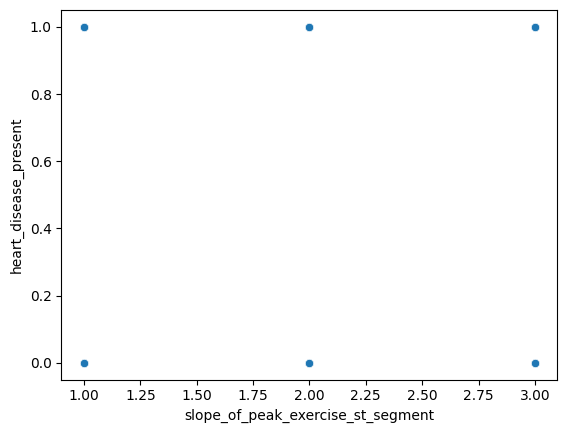

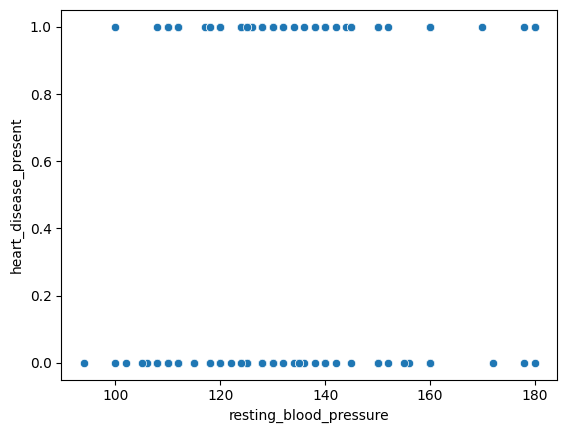

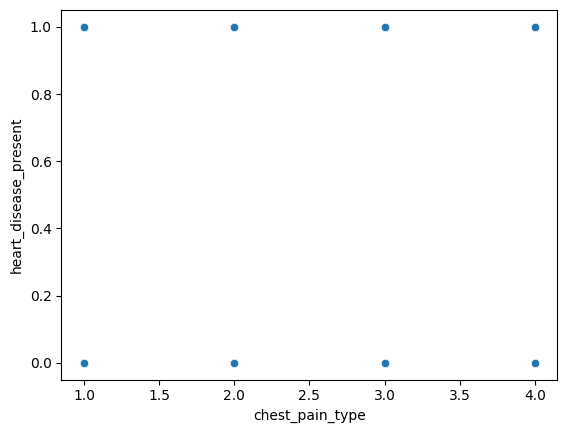

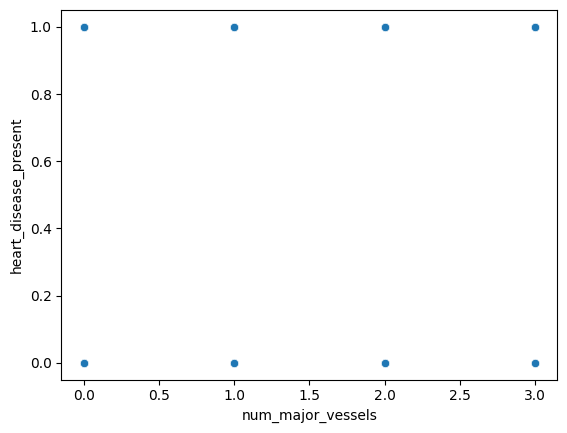

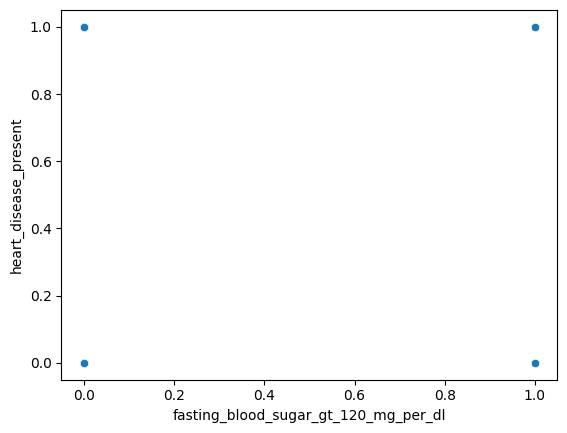

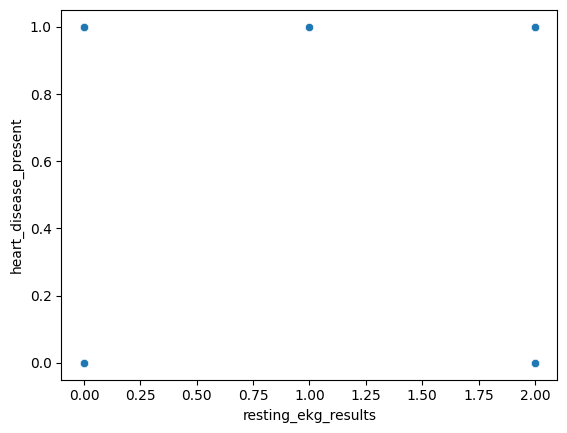

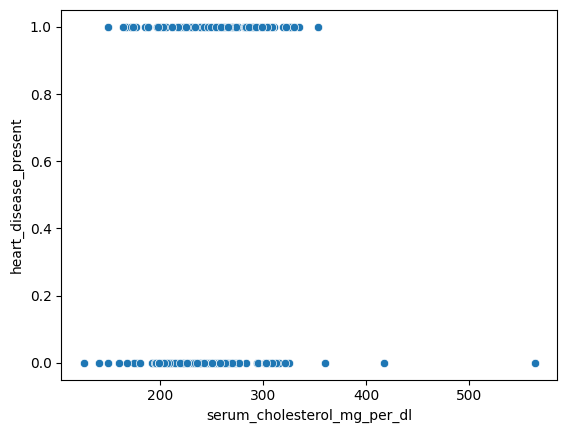

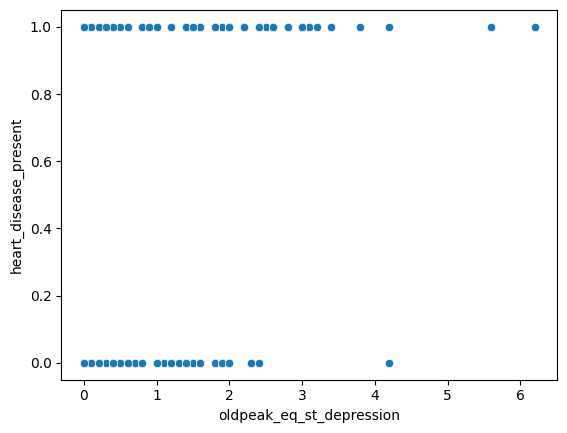

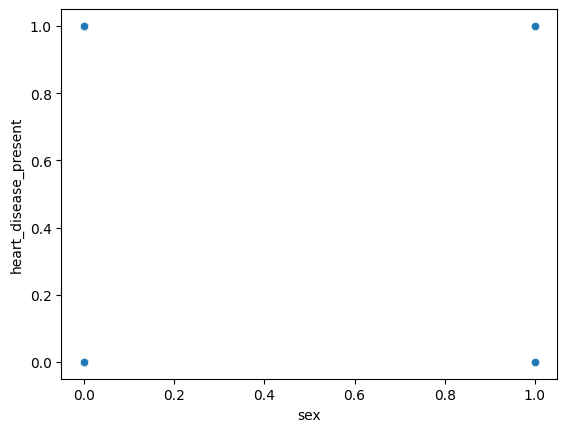

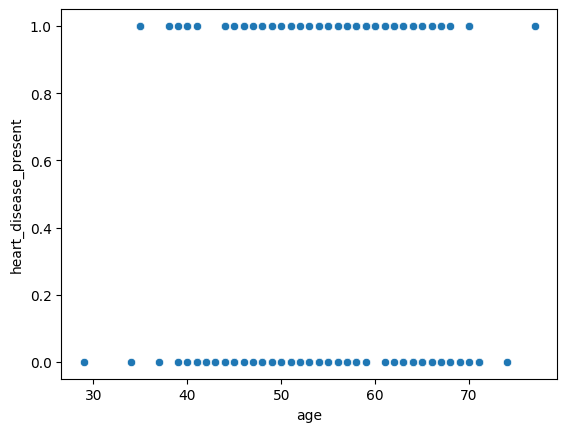

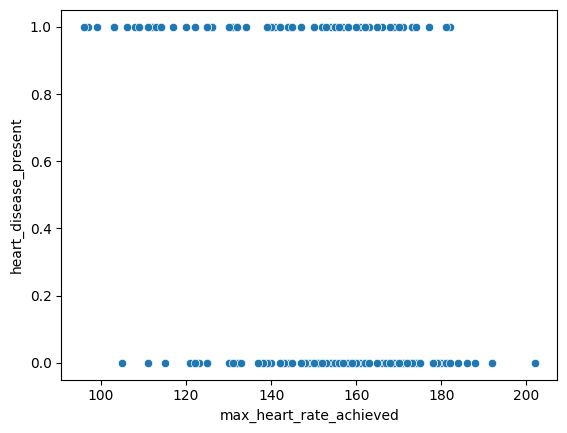

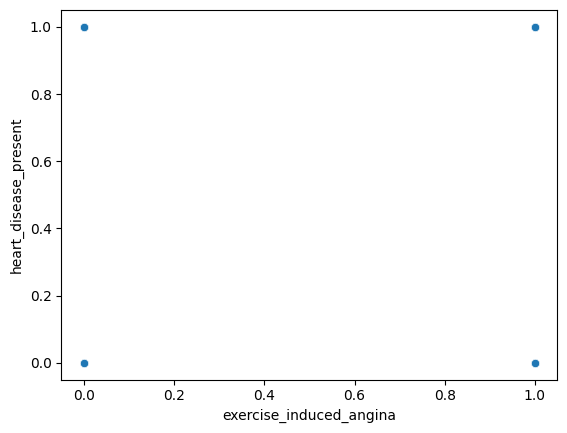

In [22]:
for i in C:
  sns.scatterplot(x=df[i],y=df['heart_disease_present'])
  plt.show()

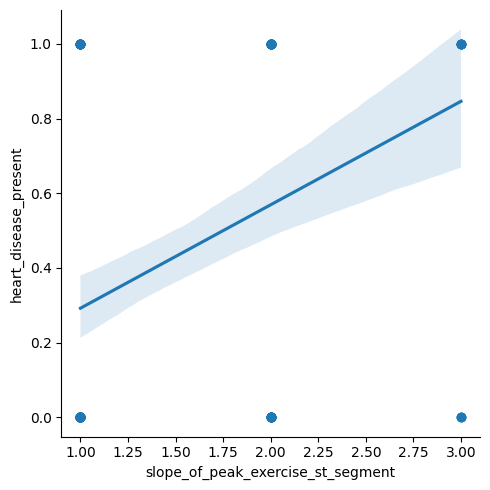

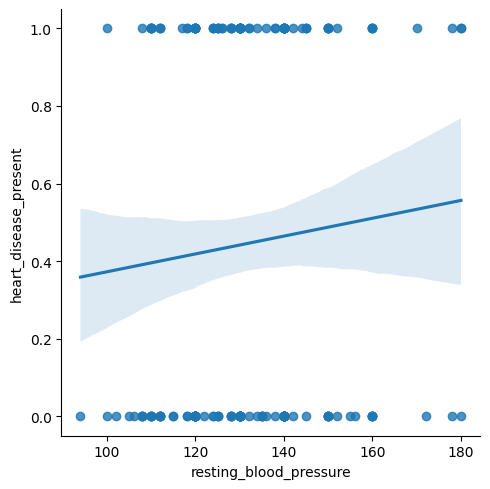

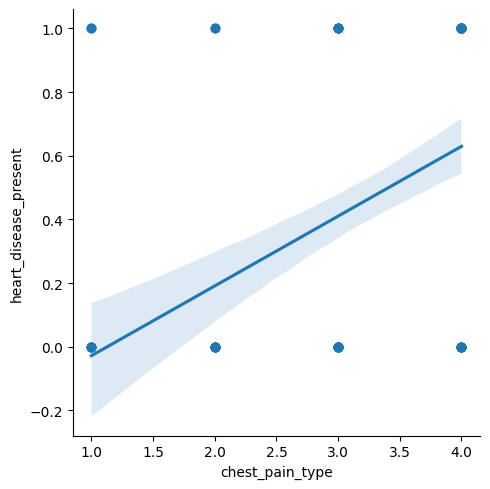

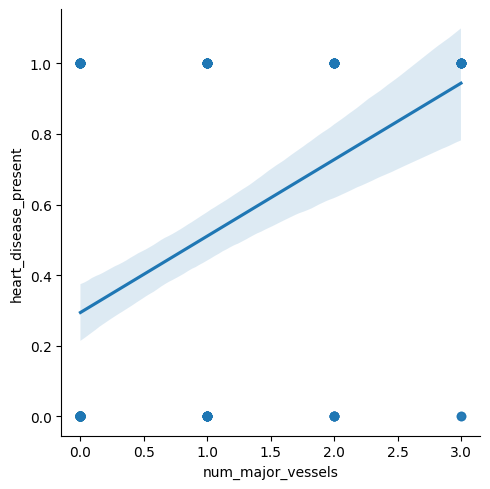

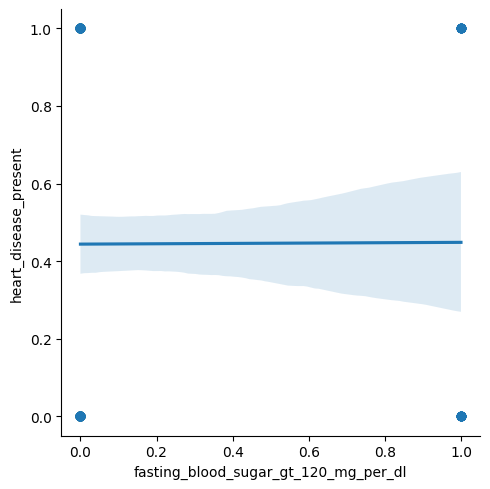

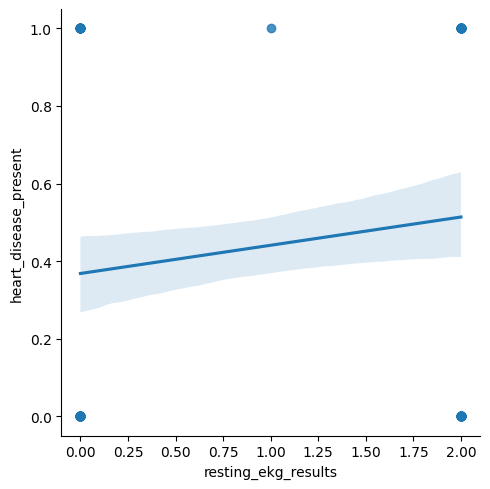

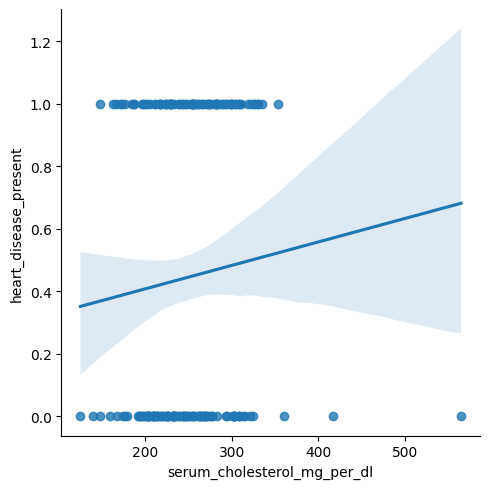

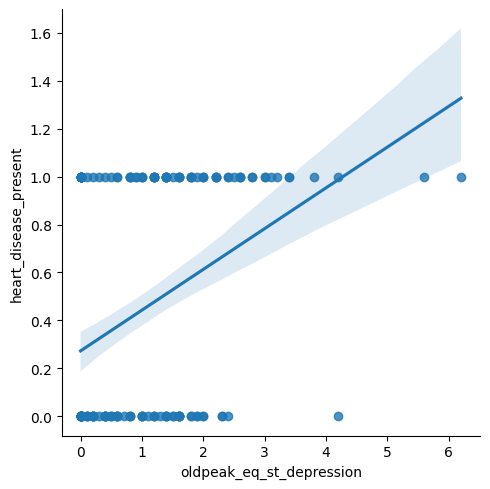

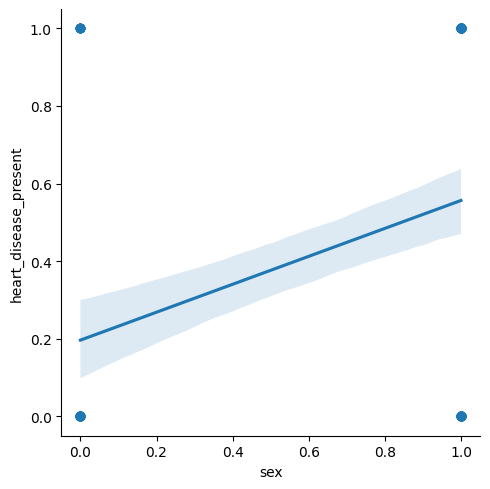

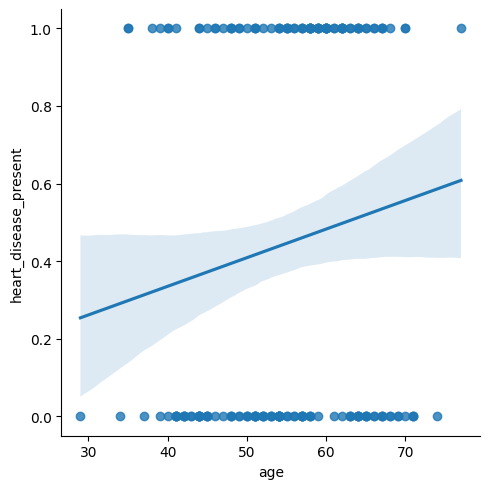

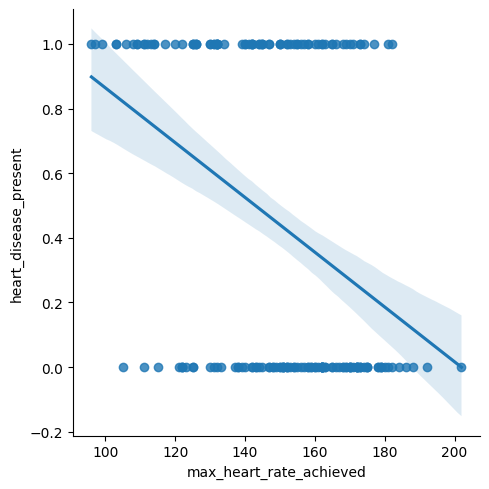

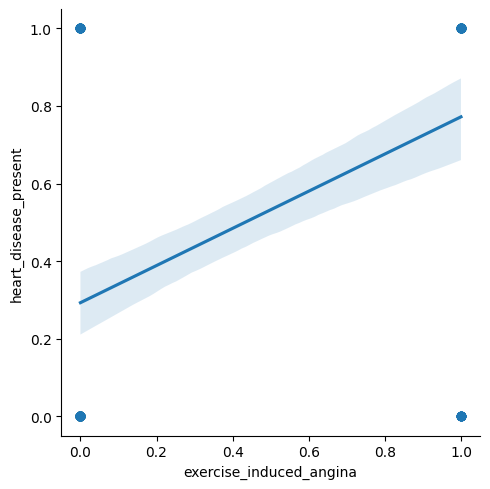

In [23]:
for i in C:
  sns.lmplot(x=i, y='heart_disease_present', data=df,fit_reg=True)
  plt.show()

1. Chest Pain: Higher chest pain types (3 & 4) show more heart disease cases Chest pain is one of the strongest indicators, Patients with type 4 have highest heart disease risk
2. Number of Major Vessels: 0 vessels indicates mostly No heart disease
1 to 3 vessels Indicates heart disease increases significantly
3. Oldpeak: Higher oldpeak values (>2) show more heart disease
4. Maximum Heart Rate Achieved: Lower heart rate shows more heart disease
6. Age: Heart disease increases with age > 50

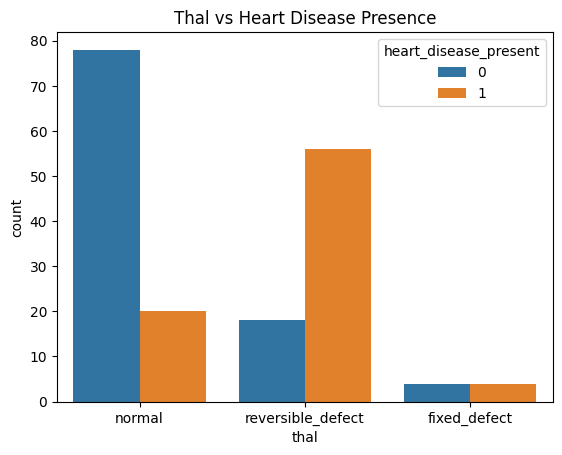

In [24]:
sns.countplot(x='thal', hue='heart_disease_present', data=df)
plt.title("Thal vs Heart Disease Presence")
plt.show()

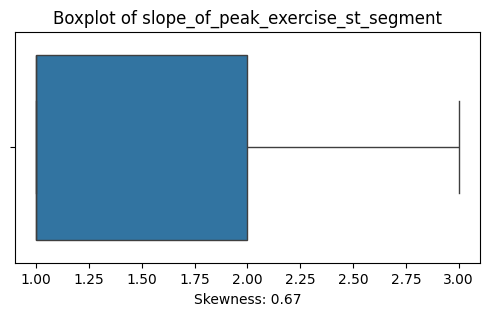

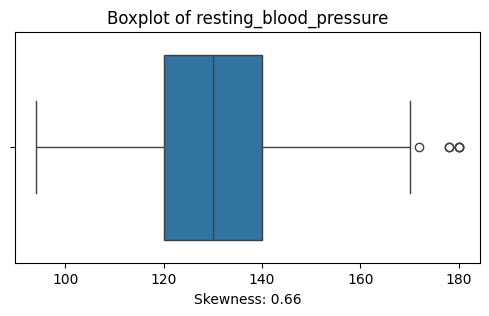

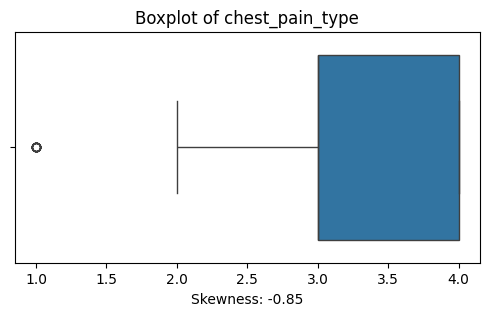

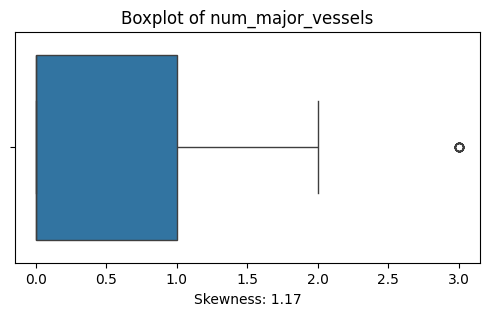

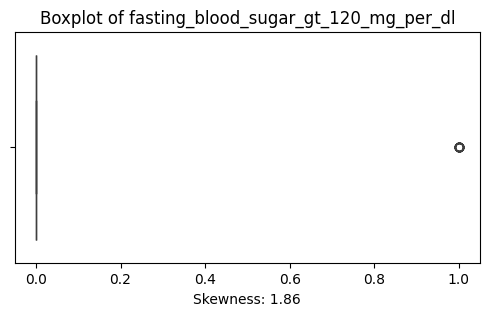

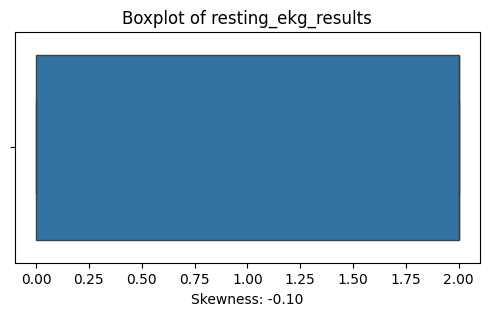

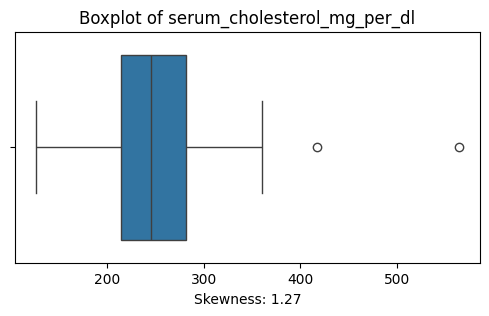

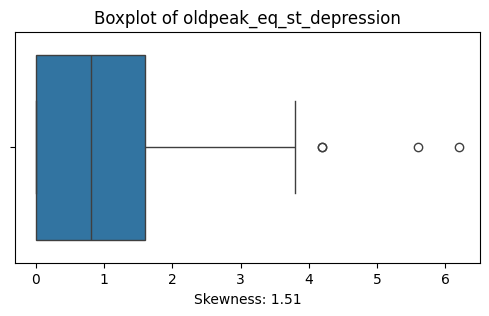

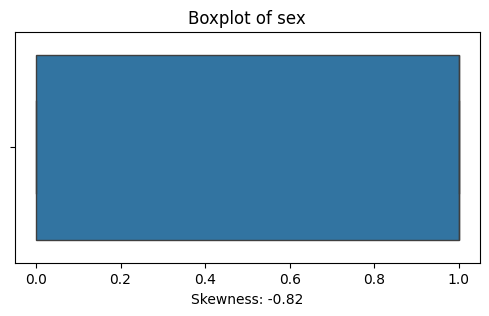

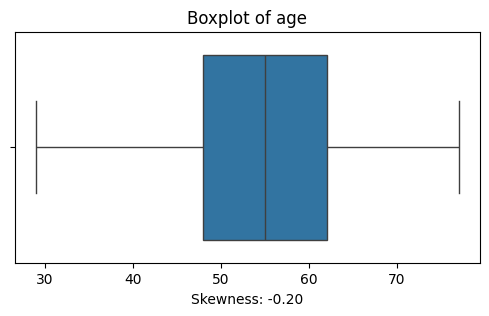

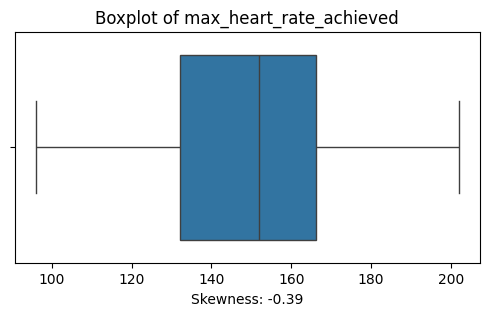

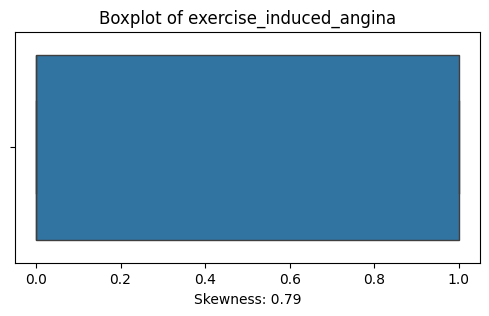

In [26]:
for col in C:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    skewness = df[col].skew()
    plt.xlabel(f'Skewness: {skewness:.2f}')
    plt.show()

In [27]:
skewness = df[C].skew().sort_values(ascending=False)
print("Skewness of Numeric Columns:")
print(skewness)

Skewness of Numeric Columns:
fasting_blood_sugar_gt_120_mg_per_dl    1.859153
oldpeak_eq_st_depression                1.507412
serum_cholesterol_mg_per_dl             1.273932
num_major_vessels                       1.167999
exercise_induced_angina                 0.794871
slope_of_peak_exercise_st_segment       0.666150
resting_blood_pressure                  0.657080
resting_ekg_results                    -0.100967
age                                    -0.199166
max_heart_rate_achieved                -0.393705
sex                                    -0.822900
chest_pain_type                        -0.849258
dtype: float64


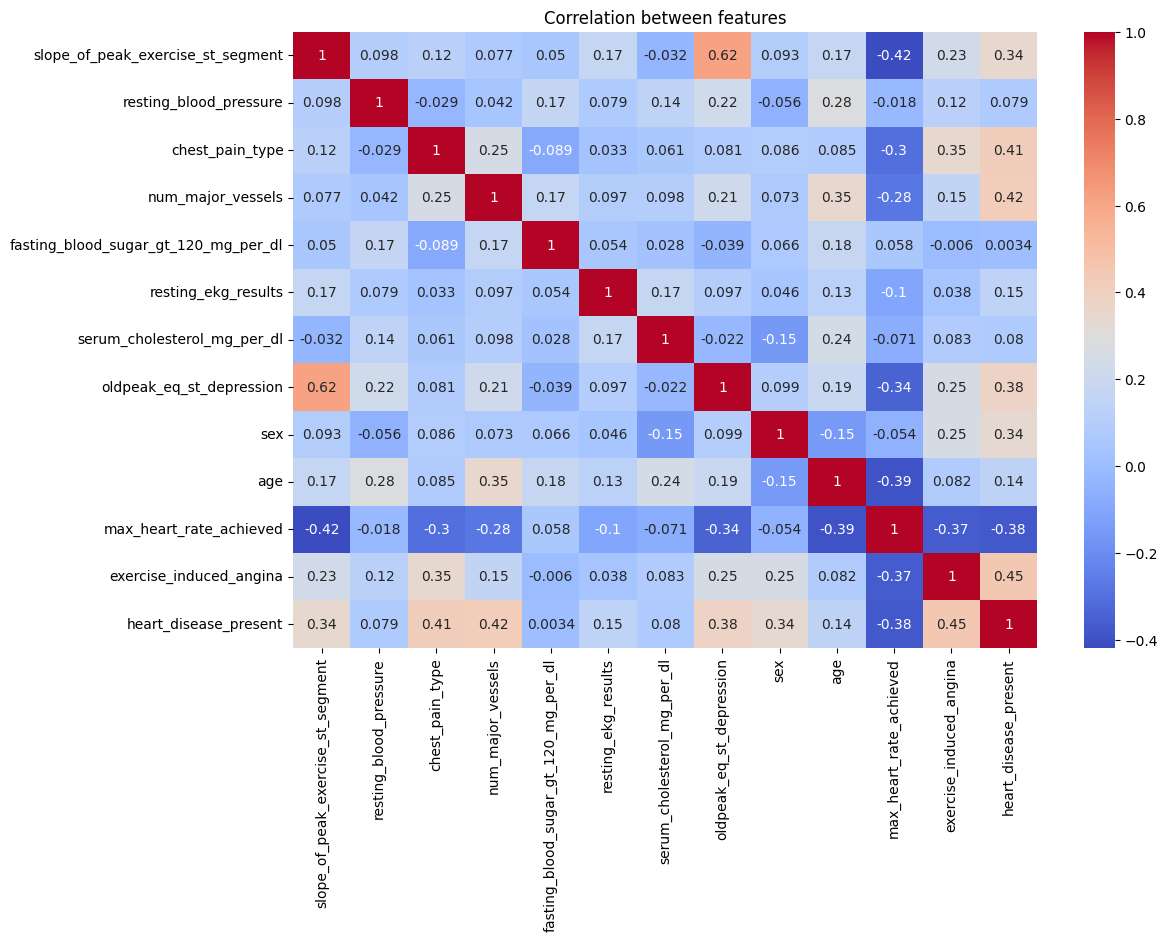

In [28]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation between features')
plt.show()

In this Dataset There is no strong corelation between two features

In [29]:
!pip install ydata-profiling
import ydata_profiling
try:
    from ydata_profiling import ProfileReport
    report = ProfileReport(df, title="EDA", explorative=False)
    # Display inline in notebook if environment supports it
    try:
        report.to_notebook_iframe()
    except Exception:
        print("ProfileReport generated (not displayed inline).")
except Exception as e:
    print("ydata_profiling not available or failed to run:", e)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.1 MB/s eta 0:00:00


/tmp/ipykernel_2819/1646901673.py:2: DeprecationWarning:


    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 63.69it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [30]:
def Outliers(df,Columns1):
  for col in Columns1:
      Q1 = df[col].quantile(0.25)
      Q3 = df[col].quantile(0.75)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5 * IQR
      upper_bound = Q3 + 1.5 * IQR

      df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
      df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

      print(f"Outliers treated for column: {col}")

In [31]:
for i in C:
  print(df[i].value_counts())

slope_of_peak_exercise_st_segment
1    93
2    75
3    12
Name: count, dtype: int64
resting_blood_pressure
130    26
140    22
120    21
110    11
150    10
160     9
112     8
128     8
125     7
124     5
108     5
135     4
145     4
118     4
180     3
138     3
132     3
100     2
178     2
136     2
152     2
134     2
126     2
142     2
115     2
102     1
94      1
144     1
170     1
155     1
156     1
117     1
106     1
122     1
172     1
105     1
Name: count, dtype: int64
chest_pain_type
4    82
3    57
2    28
1    13
Name: count, dtype: int64
num_major_vessels
0    106
1     37
2     23
3     14
Name: count, dtype: int64
fasting_blood_sugar_gt_120_mg_per_dl
0    151
1     29
Name: count, dtype: int64
resting_ekg_results
2    94
0    85
1     1
Name: count, dtype: int64
serum_cholesterol_mg_per_dl
239    4
204    4
219    3
211    3
263    3
      ..
126    1
207    1
417    1
225    1
236    1
Name: count, Length: 118, dtype: int64
oldpeak_eq_st_depression
0.0    56
1

Performing Outlier treatment for only Continous Numerical features and exclude binary and categorical columns from outlier treatment. used Capping technique for outlier treatment

In [32]:
Outliers(df,['resting_blood_pressure','serum_cholesterol_mg_per_dl','oldpeak_eq_st_depression'])

Outliers treated for column: resting_blood_pressure
Outliers treated for column: serum_cholesterol_mg_per_dl
Outliers treated for column: oldpeak_eq_st_depression


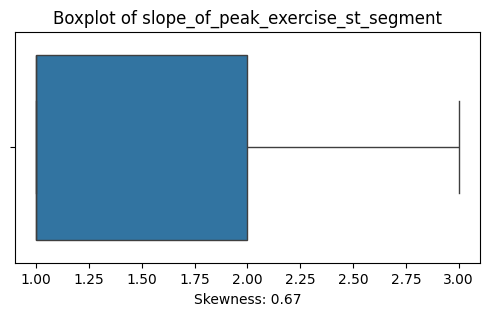

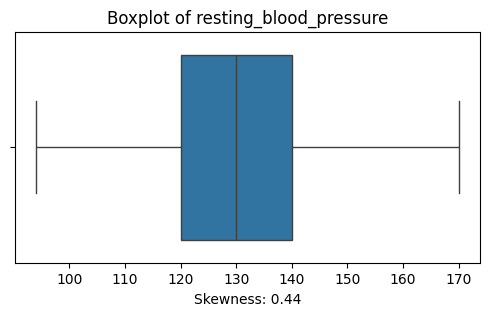

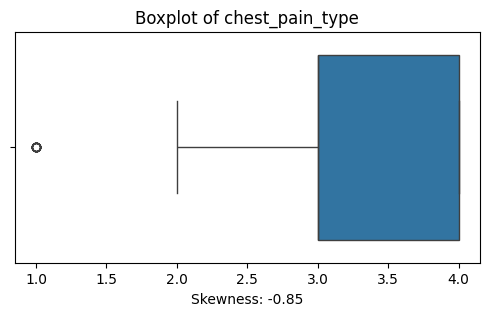

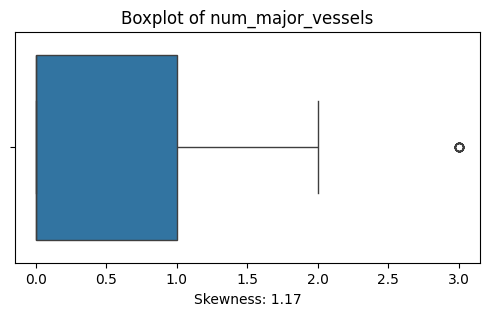

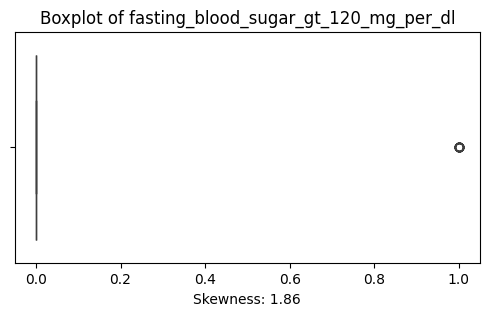

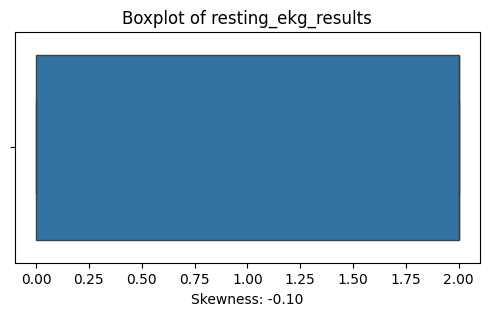

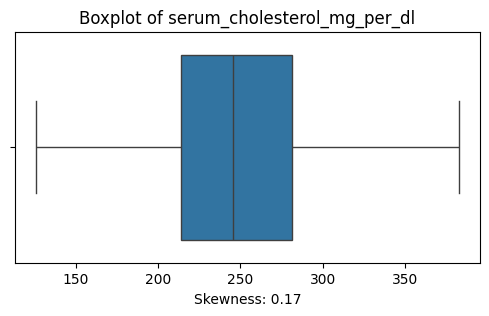

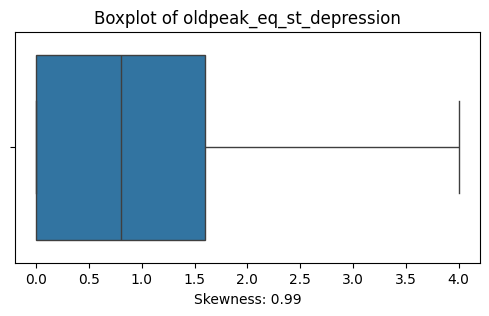

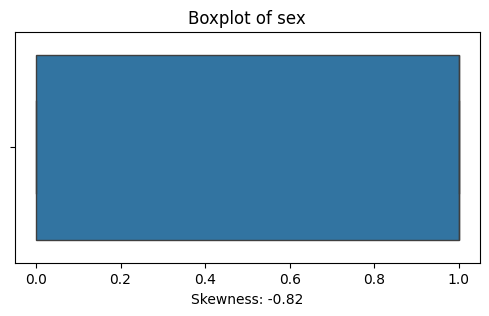

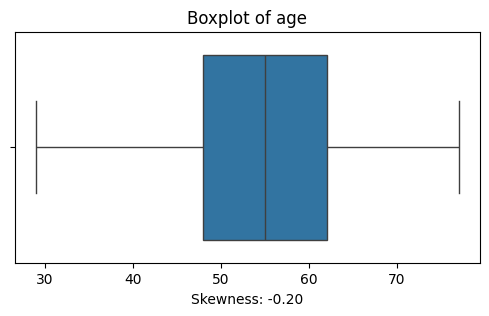

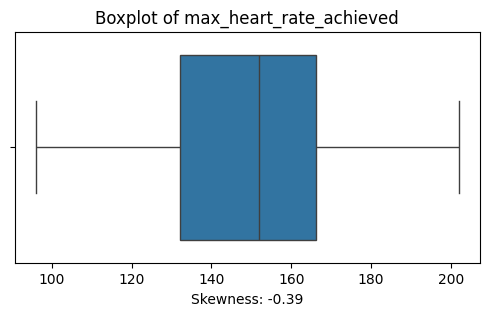

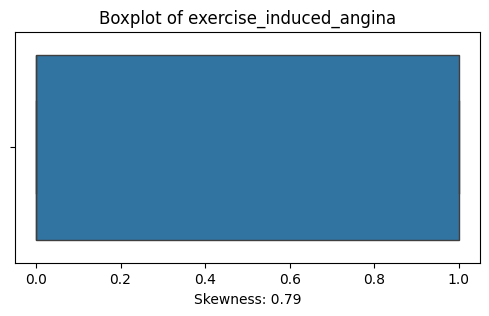

In [33]:
for col in C:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    skewness = df[col].skew()
    plt.xlabel(f'Skewness: {skewness:.2f}')
    plt.show()

In [34]:
skewness = df[C].skew().sort_values(ascending=False)
print("Skewness of Numeric Columns After Capping:")
print(skewness)

Skewness of Numeric Columns After Capping:
fasting_blood_sugar_gt_120_mg_per_dl    1.859153
num_major_vessels                       1.167999
oldpeak_eq_st_depression                0.989714
exercise_induced_angina                 0.794871
slope_of_peak_exercise_st_segment       0.666150
resting_blood_pressure                  0.443594
serum_cholesterol_mg_per_dl             0.173844
resting_ekg_results                    -0.100967
age                                    -0.199166
max_heart_rate_achieved                -0.393705
sex                                    -0.822900
chest_pain_type                        -0.849258
dtype: float64


In [35]:
df['fasting_blood_sugar_gt_120_mg_per_dl'].value_counts()

,count
fasting_blood_sugar_gt_120_mg_per_dl,
0,151
1,29


In [36]:
df.shape

(180, 14)

Skewness treatment for only Continous Numerical features and exclude binary and categorical columns

In [37]:
df['oldpeak_eq_st_depression'] = np.log1p(df['oldpeak_eq_st_depression'])
print(f"Transformed Skew: {df['oldpeak_eq_st_depression'].skew():.2f}")


Transformed Skew: 0.29


In [38]:
skewness = df[C].skew().sort_values(ascending=False)
print("Skewness of Numeric Columns After Traansformation:")
print(skewness)

Skewness of Numeric Columns After Traansformation:
fasting_blood_sugar_gt_120_mg_per_dl    1.859153
num_major_vessels                       1.167999
exercise_induced_angina                 0.794871
slope_of_peak_exercise_st_segment       0.666150
resting_blood_pressure                  0.443594
oldpeak_eq_st_depression                0.293051
serum_cholesterol_mg_per_dl             0.173844
resting_ekg_results                    -0.100967
age                                    -0.199166
max_heart_rate_achieved                -0.393705
sex                                    -0.822900
chest_pain_type                        -0.849258
dtype: float64


In [39]:
df.columns

Index(['slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [40]:
# Calculate percentage of patients with heart disease
heart = (sum(df['heart_disease_present']) / len(df['heart_disease_present'].index)) * 100
heart

44.44444444444444

In [41]:
df['thal'].value_counts()

,count
thal,
normal,98
reversible_defect,74
fixed_defect,8


In [42]:
df= pd.get_dummies(df, columns=['thal'], prefix='thal')

In [43]:
df.head()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,thal_fixed_defect,thal_normal,thal_reversible_defect
0,1,140.0,1,2,0,0,239.0,1.029619,0,69,151,0,0,False,True,False
1,1,120.0,4,0,0,0,177.0,0.336472,1,65,140,0,0,False,False,True
2,2,128.0,4,1,0,0,263.0,0.182322,1,64,105,1,0,False,False,True
3,1,170.0,4,0,0,0,325.0,0.000000,0,64,154,1,0,False,True,False
4,2,102.0,4,0,0,2,265.0,0.470004,0,42,122,0,0,False,True,False


In [44]:
# Convert all True/False columns to 1/0
df = df.astype({col: int for col in df.columns if df[col].dtype == 'bool'})

In [45]:
df.head()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present,thal_fixed_defect,thal_normal,thal_reversible_defect
0,1,140.0,1,2,0,0,239.0,1.029619,0,69,151,0,0,0,1,0
1,1,120.0,4,0,0,0,177.0,0.336472,1,65,140,0,0,0,0,1
2,2,128.0,4,1,0,0,263.0,0.182322,1,64,105,1,0,0,0,1
3,1,170.0,4,0,0,0,325.0,0.000000,0,64,154,1,0,0,1,0
4,2,102.0,4,0,0,2,265.0,0.470004,0,42,122,0,0,0,1,0


In [46]:
X = df.drop('heart_disease_present',axis=1)
y = df['heart_disease_present']

In [47]:
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2,stratify= y, random_state=42)

Standard Scaler for only Continous Numerical features and exclude binary and categorical columns

In [48]:
from sklearn.preprocessing import StandardScaler
scaler_full = StandardScaler()
cols_to_scale = ['age', 'resting_blood_pressure', 'serum_cholesterol_mg_per_dl',
                 'max_heart_rate_achieved', 'oldpeak_eq_st_depression']
X_train[cols_to_scale] = scaler_full.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler_full.transform(X_test[cols_to_scale])
print("Data successfully scaled!")

Data successfully scaled!


In [49]:
heart = df['heart_disease_present'].mean() * 100
heart

np.float64(44.44444444444444)

**Logistic Regression**

In [50]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr= lr.predict(X_test)
print("\n Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test,lr.predict_proba(X_test)[:, 1]))
print("Classification Report\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_lr))


 Logistic Regression
Accuracy: 0.8055555555555556
ROC AUC: 0.8812500000000001
Classification Report
               precision    recall  f1-score   support

           0       0.84      0.80      0.82        20
           1       0.76      0.81      0.79        16

    accuracy                           0.81        36
   macro avg       0.80      0.81      0.80        36
weighted avg       0.81      0.81      0.81        36

Confusion Matrix:
 [[16  4]
 [ 3 13]]


**SVM**

In [51]:
from sklearn.svm import SVC
svm = SVC(probability = True, kernel='rbf',random_state = 42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("\n SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("ROC AUC:", roc_auc_score(y_test,svm.predict_proba(X_test)[:, 1]))
print("Classification Report\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_svm))


 SVM
Accuracy: 0.8333333333333334
ROC AUC: 0.88125
Classification Report
               precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.81      0.81      0.81        16

    accuracy                           0.83        36
   macro avg       0.83      0.83      0.83        36
weighted avg       0.83      0.83      0.83        36

Confusion Matrix:
 [[17  3]
 [ 3 13]]


In [52]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

# Parameter distribution
param_dist = {
    'C': uniform(0.1, 10),
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

# RandomizedSearchCV
svm_random = RandomizedSearchCV(
    SVC(probability=True),
    param_dist,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

svm_random.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", svm_random.best_params_)

# Predict
y_pred_svm_tuning = svm_random.predict(X_test)

# Evaluate
print("\nSVM after Fine Tuning")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_tuning))
print("ROC AUC:", roc_auc_score(y_test, svm_random.predict_proba(X_test)[:, 1]))
print("Classification Report\n", classification_report(y_test, y_pred_svm_tuning))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_tuning))

Best Parameters: {'C': np.float64(0.30584494295802445), 'gamma': 'auto', 'kernel': 'poly'}

SVM after Fine Tuning
Accuracy: 0.8611111111111112
ROC AUC: 0.896875
Classification Report
               precision    recall  f1-score   support

           0       0.86      0.90      0.88        20
           1       0.87      0.81      0.84        16

    accuracy                           0.86        36
   macro avg       0.86      0.86      0.86        36
weighted avg       0.86      0.86      0.86        36

Confusion Matrix:
 [[18  2]
 [ 3 13]]


In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 0.2, 0.3, 0.5, 1, 2],
    'gamma': ['scale', 'auto'],
    'kernel': ['poly'],
    'degree': [2, 3, 4, 5]
}

grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

y_pred = grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, grid.predict_proba(X_test)[:,1]))

Best Parameters: {'C': 0.5, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
Accuracy: 0.8611111111111112
ROC AUC: 0.890625


In [54]:
train_acc = svm_random.best_estimator_.score(X_train, y_train)

# Test Accuracy
test_acc = svm_random.best_estimator_.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.9097222222222222
Test Accuracy: 0.8611111111111112


There is no Overfitting Found

**Decision Tree**

In [55]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("\n Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_test,dt.predict_proba(X_test)[:, 1]))
print("Classification Report\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_dt))


 Decision Tree
Accuracy: 0.7222222222222222
ROC AUC: 0.7312500000000001
Classification Report
               precision    recall  f1-score   support

           0       0.81      0.65      0.72        20
           1       0.65      0.81      0.72        16

    accuracy                           0.72        36
   macro avg       0.73      0.73      0.72        36
weighted avg       0.74      0.72      0.72        36

Confusion Matrix:
 [[13  7]
 [ 3 13]]


In [56]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=200,
    random_state=42,
    bootstrap= True
)

bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)

print("\nBagging Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print("ROC AUC:", roc_auc_score(y_test, bag.predict_proba(X_test)[:, 1]))
print("Classification Report\n", classification_report(y_test, y_pred_bag))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bag))


Bagging Classifier
Accuracy: 0.75
ROC AUC: 0.8781249999999999
Classification Report
               precision    recall  f1-score   support

           0       0.82      0.70      0.76        20
           1       0.68      0.81      0.74        16

    accuracy                           0.75        36
   macro avg       0.75      0.76      0.75        36
weighted avg       0.76      0.75      0.75        36

Confusion Matrix:
 [[14  6]
 [ 3 13]]


**Random Forest**

In [57]:
from sklearn.ensemble import RandomForestClassifier
rf_original = RandomForestClassifier(n_estimators=50, random_state=42)
rf_original.fit(X_train, y_train)
y_pred_rf = rf_original.predict(X_test)
print("\n Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test,rf_original.predict_proba(X_test)[:, 1]))
print("Classification Report\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_rf))


 Random Forest
Accuracy: 0.8055555555555556
ROC AUC: 0.8703125
Classification Report
               precision    recall  f1-score   support

           0       0.84      0.80      0.82        20
           1       0.76      0.81      0.79        16

    accuracy                           0.81        36
   macro avg       0.80      0.81      0.80        36
weighted avg       0.81      0.81      0.81        36

Confusion Matrix:
 [[16  4]
 [ 3 13]]


In [58]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rfc_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}
rfc_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rfc_dist,
    n_iter=200,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42
)
rfc_random.fit(X_train, y_train)
best_rfc = rfc_random.best_estimator_

y_pred_rfc = best_rfc.predict(X_test)
y_prob_rfc = best_rfc.predict_proba(X_test)[:, 1]

print("\nRandom Forest (After RandomizedSearchCV Tuning):")
print("Accuracy:", accuracy_score(y_test, y_pred_rfc))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rfc))
print(classification_report(y_test, y_pred_rfc))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rfc))


Random Forest (After RandomizedSearchCV Tuning):
Accuracy: 0.8055555555555556
ROC AUC: 0.878125
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        20
           1       0.76      0.81      0.79        16

    accuracy                           0.81        36
   macro avg       0.80      0.81      0.80        36
weighted avg       0.81      0.81      0.81        36

Confusion Matrix:
 [[16  4]
 [ 3 13]]


**Gradient Boosting Classifier**

In [59]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

gb_initial = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
gb_initial.fit(X_train, y_train)
y_pred_gb = gb_initial.predict(X_test)

print("\nGradient Boosting Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("ROC AUC:", roc_auc_score(y_test, gb_initial.predict_proba(X_test)[:, 1]))
print(classification_report(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))


Gradient Boosting Classifier:
Accuracy: 0.7777777777777778
ROC AUC: 0.8656250000000001
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        20
           1       0.72      0.81      0.76        16

    accuracy                           0.78        36
   macro avg       0.78      0.78      0.78        36
weighted avg       0.78      0.78      0.78        36

Confusion Matrix:
 [[15  5]
 [ 3 13]]


In [60]:
# Hyperparameter Tuning for Gradient Boosting Classifier using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Parameter Distributions (faster search)
gbc_dist = {
    'n_estimators': randint(100, 400),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(2, 6),
    'subsample': uniform(0.7, 0.3),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

# Model
gbc = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

# Randomized Search
gbc_random = RandomizedSearchCV(
    estimator=gbc,
    param_distributions=gbc_dist,
    n_iter=50,              # number of random combinations
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit
gbc_random.fit(X_train, y_train)

# Best parameters
print("\nBest Hyperparameters:")
print(gbc_random.best_params_)

# Best model
best_gbc_full = gbc_random.best_estimator_

# Predictions
y_pred_gbc = best_gbc_full.predict(X_test)
y_prob_gbc = best_gbc_full.predict_proba(X_test)[:, 1]

# Evaluation
print("\nGradient Boosting (After RandomizedSearchCV Tuning):")
print("Accuracy:", accuracy_score(y_test, y_pred_gbc))
print("ROC AUC:", roc_auc_score(y_test, y_prob_gbc))
print(classification_report(y_test, y_pred_gbc))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gbc))

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters:
{'learning_rate': np.float64(0.05820509320520235), 'max_depth': 5, 'min_samples_leaf': 7, 'min_samples_split': 13, 'n_estimators': 363, 'subsample': np.float64(0.7103165563345655)}

Gradient Boosting (After RandomizedSearchCV Tuning):
Accuracy: 0.8055555555555556
ROC AUC: 0.8343749999999999
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        20
           1       0.76      0.81      0.79        16

    accuracy                           0.81        36
   macro avg       0.80      0.81      0.80        36
weighted avg       0.81      0.81      0.81        36

Confusion Matrix:
 [[16  4]
 [ 3 13]]


**XG Boost**

In [61]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))


XGBoost:
Accuracy: 0.8055555555555556
ROC AUC: 0.86875
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        20
           1       0.76      0.81      0.79        16

    accuracy                           0.81        36
   macro avg       0.80      0.81      0.80        36
weighted avg       0.81      0.81      0.81        36

Confusion Matrix:
 [[16  4]
 [ 3 13]]


"Best Feature Selection"

In [62]:
from sklearn.feature_selection import RFE
rf = RandomForestClassifier(random_state=42)
rfe = RFE(rf, n_features_to_select=8)
X_selected = rfe.fit_transform(X, y)
print("Selected Features:", rfe.support_)

Selected Features: [False False  True  True False False  True  True False  True  True False
 False  True  True]


In [63]:
selected_features = X.columns[rfe.support_]
print("Selected Feature Names:")
print(selected_features)

Selected Feature Names:
Index(['chest_pain_type', 'num_major_vessels', 'serum_cholesterol_mg_per_dl',
       'oldpeak_eq_st_depression', 'age', 'max_heart_rate_achieved',
       'thal_normal', 'thal_reversible_defect'],
      dtype='object')


In [64]:
X_selected = X[selected_features]

In [65]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_selected, y, test_size=0.2, stratify = y, random_state=42)

In [66]:
scaler_s = StandardScaler()
X_train_s = scaler_s.fit_transform(X_train_s)
X_test_s = scaler_s.transform(X_test_s)

**Logistic Regression after feature Selection**

In [67]:
lr_s = LogisticRegression(max_iter=500, random_state=42)
lr_s.fit(X_train_s, y_train_s)
y_pred_lr_s= lr_s.predict(X_test_s)
print("\n Logistic Regression")
print("Accuracy:", accuracy_score(y_test_s, y_pred_lr_s))
print("ROC AUC:", roc_auc_score(y_test_s,lr_s.predict_proba(X_test_s)[:, 1]))
print("Classification Report\n", classification_report(y_test_s, y_pred_lr_s))
print("Confusion Matrix:\n",confusion_matrix(y_test_s, y_pred_lr_s))


 Logistic Regression
Accuracy: 0.75
ROC AUC: 0.8562500000000001
Classification Report
               precision    recall  f1-score   support

           0       0.82      0.70      0.76        20
           1       0.68      0.81      0.74        16

    accuracy                           0.75        36
   macro avg       0.75      0.76      0.75        36
weighted avg       0.76      0.75      0.75        36

Confusion Matrix:
 [[14  6]
 [ 3 13]]


**Decision tree after feature selectin**

In [68]:
from sklearn.tree import DecisionTreeClassifier
dt_s = DecisionTreeClassifier(random_state=42)
dt_s.fit(X_train_s, y_train_s)
y_pred_dt_s = dt_s.predict(X_test_s)
print("\n Decision Tree")
print("Accuracy:", accuracy_score(y_test_s, y_pred_dt_s))
print("ROC AUC:", roc_auc_score(y_test_s,dt_s.predict_proba(X_test_s)[:, 1]))
print("Classification Report\n", classification_report(y_test_s, y_pred_dt_s))
print("Confusion Matrix:\n",confusion_matrix(y_test_s, y_pred_dt_s))


 Decision Tree
Accuracy: 0.7222222222222222
ROC AUC: 0.7249999999999999
Classification Report
               precision    recall  f1-score   support

           0       0.78      0.70      0.74        20
           1       0.67      0.75      0.71        16

    accuracy                           0.72        36
   macro avg       0.72      0.72      0.72        36
weighted avg       0.73      0.72      0.72        36

Confusion Matrix:
 [[14  6]
 [ 4 12]]


**SVM after Feature Selection**

In [69]:
from sklearn.svm import SVC
svm_s = SVC(probability = True, kernel='rbf',random_state = 42)
svm_s.fit(X_train_s, y_train_s)
y_pred_svm_s= svm_s.predict(X_test_s)
print("\n SVM")
print("Accuracy:", accuracy_score(y_test_s, y_pred_svm_s))
print("ROC AUC:", roc_auc_score(y_test_s,svm_s.predict_proba(X_test_s)[:, 1]))
print("Classification Report\n", classification_report(y_test_s, y_pred_svm_s))
print("Confusion Matrix:\n",confusion_matrix(y_test_s, y_pred_svm_s))


 SVM
Accuracy: 0.75
ROC AUC: 0.85
Classification Report
               precision    recall  f1-score   support

           0       0.82      0.70      0.76        20
           1       0.68      0.81      0.74        16

    accuracy                           0.75        36
   macro avg       0.75      0.76      0.75        36
weighted avg       0.76      0.75      0.75        36

Confusion Matrix:
 [[14  6]
 [ 3 13]]


**Random Forest after Feature Selection**

In [70]:
from sklearn.ensemble import RandomForestClassifier
rf_s = RandomForestClassifier(n_estimators=50, random_state=42)
rf_s.fit(X_train_s, y_train_s)
y_pred_rf_s = rf_s.predict(X_test_s)
print("\n Random Forest")
print("Accuracy:", accuracy_score(y_test_s, y_pred_rf_s))
print("ROC AUC:", roc_auc_score(y_test_s,rf_s.predict_proba(X_test_s)[:, 1]))
print("Classification Report\n", classification_report(y_test_s, y_pred_rf_s))
print("Confusion Matrix:\n",confusion_matrix(y_test_s, y_pred_rf_s))


 Random Forest
Accuracy: 0.75
ROC AUC: 0.8515625
Classification Report
               precision    recall  f1-score   support

           0       0.82      0.70      0.76        20
           1       0.68      0.81      0.74        16

    accuracy                           0.75        36
   macro avg       0.75      0.76      0.75        36
weighted avg       0.76      0.75      0.75        36

Confusion Matrix:
 [[14  6]
 [ 3 13]]


In [71]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rfc_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}
rfc_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rfc_dist,
    n_iter=200,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42
)
rfc_random.fit(X_train_s, y_train_s)
best_rfc = rfc_random.best_estimator_

y_pred_rfc = best_rfc.predict(X_test_s)
y_prob_rfc = best_rfc.predict_proba(X_test_s)[:, 1]

print("\nRandom Forest (After RandomizedSearchCV Tuning):")
print("Accuracy:", accuracy_score(y_test_s, y_pred_rfc))
print("ROC AUC:", roc_auc_score(y_test_s, y_prob_rfc))
print(classification_report(y_test_s, y_pred_rfc))
print("Confusion Matrix:\n", confusion_matrix(y_test_s, y_pred_rfc))


Random Forest (After RandomizedSearchCV Tuning):
Accuracy: 0.75
ROC AUC: 0.8625
              precision    recall  f1-score   support

           0       0.82      0.70      0.76        20
           1       0.68      0.81      0.74        16

    accuracy                           0.75        36
   macro avg       0.75      0.76      0.75        36
weighted avg       0.76      0.75      0.75        36

Confusion Matrix:
 [[14  6]
 [ 3 13]]


**Gradient Boos after Feature Selection**

In [72]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

gb_selected_features = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
gb_selected_features.fit(X_train_s, y_train_s)
y_pred_gb_s = gb_selected_features.predict(X_test_s)

print("\nGradient Boosting Classifier:")
print("Accuracy:", accuracy_score(y_test_s, y_pred_gb_s))
print("ROC AUC:", roc_auc_score(y_test_s, gb_selected_features.predict_proba(X_test_s)[:, 1]))
print(classification_report(y_test_s, y_pred_gb_s))
print("Confusion Matrix:\n", confusion_matrix(y_test_s, y_pred_gb_s))


Gradient Boosting Classifier:
Accuracy: 0.7777777777777778
ROC AUC: 0.85
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        20
           1       0.72      0.81      0.76        16

    accuracy                           0.78        36
   macro avg       0.78      0.78      0.78        36
weighted avg       0.78      0.78      0.78        36

Confusion Matrix:
 [[15  5]
 [ 3 13]]


In [73]:
# Hyperparameter Tuning for Gradient Boosting Classifier using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Parameter Distributions (faster search)
gbc_dist = {
    'n_estimators': randint(100, 400),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(2, 6),
    'subsample': uniform(0.7, 0.3),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

# Model
gbc = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

# Randomized Search
gbc_random = RandomizedSearchCV(
    estimator=gbc,
    param_distributions=gbc_dist,
    n_iter=50,              # number of random combinations
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit
gbc_random.fit(X_train_s, y_train_s)

# Best parameters
print("\nBest Hyperparameters:")
print(gbc_random.best_params_)

# Best model
best_gbc_selected = gbc_random.best_estimator_

# Predictions
y_pred_gbc_s = best_gbc_selected.predict(X_test_s)
y_prob_gbc_s = best_gbc_selected.predict_proba(X_test_s)[:, 1]

# Evaluation
print("\nGradient Boosting (After RandomizedSearchCV Tuning):")
print("Accuracy:", accuracy_score(y_test_s, y_pred_gbc_s))
print("ROC AUC:", roc_auc_score(y_test_s, y_prob_gbc_s))
print(classification_report(y_test_s, y_pred_gbc_s))
print("Confusion Matrix:\n", confusion_matrix(y_test_s, y_pred_gbc_s))

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters:
{'learning_rate': np.float64(0.012652992231973307), 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 152, 'subsample': np.float64(0.7692681476866446)}

Gradient Boosting (After RandomizedSearchCV Tuning):
Accuracy: 0.7777777777777778
ROC AUC: 0.8312499999999999
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        20
           1       0.72      0.81      0.76        16

    accuracy                           0.78        36
   macro avg       0.78      0.78      0.78        36
weighted avg       0.78      0.78      0.78        36

Confusion Matrix:
 [[15  5]
 [ 3 13]]


In [74]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

# Model Results
model_results = {
    "Model": [
        "Logistic Regression",
        "SVM",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting (Full)",
        "XGBoost",
        "Tuned SVM",
        "Logistic Regression (Feature Selection)",
        "SVM (Feature Selection)",
        "Decision Tree (Feature Selection)",
        "Random Forest (Feature Selection)",
        "Gradient Boosting (Feature Selection)",
        "Tuned Gradient Boosting (Feature Selection)"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, gb_initial.predict(X_test)),
        accuracy_score(y_test, best_gbc_full.predict(X_test)),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_svm_tuning),
        accuracy_score(y_test_s, y_pred_lr_s),
        accuracy_score(y_test_s, y_pred_svm_s),
        accuracy_score(y_test_s, y_pred_dt_s),
        accuracy_score(y_test_s, y_pred_rf_s),
        accuracy_score(y_test_s, gb_selected_features.predict(X_test_s)),
        accuracy_score(y_test_s, best_gbc_selected.predict(X_test_s))
    ],

    "ROC AUC": [
        roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, svm.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf_original.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, gb_initial.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_gbc_full.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, svm_random.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test_s, lr_s.predict_proba(X_test_s)[:,1]),
        roc_auc_score(y_test_s, svm_s.predict_proba(X_test_s)[:,1]),
        roc_auc_score(y_test_s, dt_s.predict_proba(X_test_s)[:,1]),
        roc_auc_score(y_test_s, rf_s.predict_proba(X_test_s)[:,1]),
        roc_auc_score(y_test_s, gb_selected_features.predict_proba(X_test_s)[:,1]),
        roc_auc_score(y_test_s, best_gbc_selected.predict_proba(X_test_s)[:,1])
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, gb_initial.predict(X_test)),
        precision_score(y_test, best_gbc_full.predict(X_test)),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_svm_tuning),
        precision_score(y_test_s, y_pred_lr_s),
        precision_score(y_test_s, y_pred_svm_s),
        precision_score(y_test_s, y_pred_dt_s),
        precision_score(y_test_s, y_pred_rf_s),
        precision_score(y_test_s, gb_selected_features.predict(X_test_s)),
        precision_score(y_test_s, best_gbc_selected.predict(X_test_s))
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, gb_initial.predict(X_test)),
        recall_score(y_test, best_gbc_full.predict(X_test)),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_svm_tuning),
        recall_score(y_test_s, y_pred_lr_s),
        recall_score(y_test_s, y_pred_svm_s),
        recall_score(y_test_s, y_pred_dt_s),
        recall_score(y_test_s, y_pred_rf_s),
        recall_score(y_test_s, gb_selected_features.predict(X_test_s)),
        recall_score(y_test_s, best_gbc_selected.predict(X_test_s))
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, gb_initial.predict(X_test)),
        f1_score(y_test, best_gbc_full.predict(X_test)),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_svm_tuning),
        f1_score(y_test_s, y_pred_lr_s),
        f1_score(y_test_s, y_pred_svm_s),
        f1_score(y_test_s, y_pred_dt_s),
        f1_score(y_test_s, y_pred_rf_s),
        f1_score(y_test_s, gb_selected_features.predict(X_test_s)),
        f1_score(y_test_s, best_gbc_selected.predict(X_test_s))
    ]
}

# Convert to DataFrame
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,ROC AUC,Precision,Recall,F1 Score
0,Tuned SVM,0.861111,0.896875,0.866667,0.8125,0.838710
1,SVM,0.833333,0.881250,0.812500,0.8125,0.812500
2,Random Forest,0.805556,0.870313,0.764706,0.8125,0.787879
3,Tuned Gradient Boosting (Full),0.805556,0.834375,0.764706,0.8125,0.787879
4,XGBoost,0.805556,0.868750,0.764706,0.8125,0.787879
5,Logistic Regression,0.805556,0.881250,0.764706,0.8125,0.787879
6,Gradient Boosting (Feature Selection),0.777778,0.850000,0.722222,0.8125,0.764706
7,Gradient Boosting,0.777778,0.865625,0.722222,0.8125,0.764706
8,Tuned Gradient Boosting (Feature Selection),0.777778,0.831250,0.722222,0.8125,0.764706
9,SVM (Feature Selection),0.750000,0.850000,0.684211,0.8125,0.742857


In [75]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_svm_tuning
})

result['Match'] = result['Actual'] == result['Predicted']

display(result)

,Actual,Predicted,Match
29,0,0,True
164,1,1,True
75,1,1,True
168,0,0,True
42,0,0,True
131,1,1,True
41,0,0,True
139,0,0,True
2,0,1,False
46,1,1,True


In [76]:
print(X.columns)

Index(['slope_of_peak_exercise_st_segment', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'thal_fixed_defect', 'thal_normal', 'thal_reversible_defect'],
      dtype='object')


In [77]:
sample = pd.DataFrame([{
    'slope_of_peak_exercise_st_segment': 1,
    'resting_blood_pressure': 110,
    'chest_pain_type': 1,
    'num_major_vessels': 0,
    'fasting_blood_sugar_gt_120_mg_per_dl': 0,
    'resting_ekg_results': 0,
    'serum_cholesterol_mg_per_dl': 160,
    'oldpeak_eq_st_depression': 0.0,
    'sex': 0,
    'age': 29,
    'max_heart_rate_achieved': 180,
    'exercise_induced_angina': 0,
    'thal_fixed_defect': 0,
    'thal_normal': 1,
    'thal_reversible_defect': 0
}])

sample = sample[X.columns]

sample[cols_to_scale] = scaler_full.transform(sample[cols_to_scale])

prediction = svm_random.best_estimator_.predict(sample)
prob = svm_random.best_estimator_.predict_proba(sample)

print("Prediction:", prediction)
print("Probability:", prob)

Prediction: [0]
Probability: [[0.86460755 0.13539245]]


In this project, a machine learning model was developed to predict the presence of heart disease using patient clinical data. The dataset was first preprocessed by handling skewness, treating outliers, encoding categorical variables, and scaling numerical features to improve model performance.

Multiple machine learning models were trained and evaluated, including Logistic Regression, Support Vector Machine (SVM), Decision Tree, Random Forest, Gradient Boosting, and XGBoost. Additionally, feature selection techniques were applied to identify the most important features and to evaluate whether reducing feature dimensionality improves model performance. However, feature selection did not significantly improve performance, and models trained on the full feature set performed better.

Hyperparameter tuning was then performed to further optimize the models. Among all models, the Support Vector Machine (SVM) performed the best after tuning.

 **Final Best Model Performance
Model: Tuned SVM (Polynomial Kernel)
Accuracy: 86.11%
ROC AUC: 0.896
Balanced Precision, Recall, and F1 Score**

The final model demonstrated strong predictive capability and effectively classified patients with and without heart disease. This project successfully implemented a complete machine learning pipeline including data preprocessing, feature selection, model training, evaluation, and hyperparameter tuning.

Overall, the developed model can assist in early detection of heart disease and support healthcare professionals in making data-driven decisions.

In [78]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 99.3 MB/s eta 0:00:00


In [79]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("heart_model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("Heart Disease Prediction")

age = st.slider("Age", 20, 80)
sex = st.selectbox("Sex", ["Female","Male"])
chest_pain = st.selectbox("Chest Pain Type", [1,2,3,4])
bp = st.slider("Resting Blood Pressure", 90, 200)
chol = st.slider("Cholesterol", 100, 400)
max_hr = st.slider("Max Heart Rate", 70, 200)

thal = st.selectbox("Thal", ["Normal","Fixed Defect","Reversible Defect"])

sex = 1 if sex == "Male" else 0

thal_fixed = 1 if thal == "Fixed Defect" else 0
thal_normal = 1 if thal == "Normal" else 0
thal_reversible = 1 if thal == "Reversible Defect" else 0

if st.button("Predict"):

    sample = pd.DataFrame([[1,bp,chest_pain,0,0,0,chol,0.5,sex,age,max_hr,0,
                            thal_fixed,thal_normal,thal_reversible]],
    columns=['slope_of_peak_exercise_st_segment',
             'resting_blood_pressure',
             'chest_pain_type',
             'num_major_vessels',
             'fasting_blood_sugar_gt_120_mg_per_dl',
             'resting_ekg_results',
             'serum_cholesterol_mg_per_dl',
             'oldpeak_eq_st_depression',
             'sex',
             'age',
             'max_heart_rate_achieved',
             'exercise_induced_angina',
             'thal_fixed_defect',
             'thal_normal',
             'thal_reversible_defect'])

    cols_to_scale = ['age','resting_blood_pressure',
                     'serum_cholesterol_mg_per_dl',
                     'max_heart_rate_achieved',
                     'oldpeak_eq_st_depression']

    sample[cols_to_scale] = scaler.transform(sample[cols_to_scale])

    prediction = model.predict(sample)

    if prediction[0] == 1:
        st.error("Heart Disease Detected")
    else:
        st.success("No Heart Disease")

Writing app.py


In [80]:
import joblib

joblib.dump(svm_random.best_estimator_, "heart_model.pkl")
joblib.dump(scaler_full, "scaler.pkl")

['scaler.pkl']

In [81]:
%%writefile requirements.txt
streamlit
scikit-learn
pandas
numpy
joblib

Writing requirements.txt


In [82]:
from google.colab import files

files.download("app.py")
files.download("heart_model.pkl")
files.download("scaler.pkl")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>